### Michaelis-Menten Kinetics

 Mechanism: \
 E + S -> ES  ||   kf * E * S \
 ES -> E + S  ||   kf * ES \
 ES -> E + P  ||   kp * ES

Where:
- E is the enzyme.
- S is the substrate.
- ES  is the enzyme-substrate complex.
- P is the product.

Below is a sample simulation, where QSSA will be appropriate

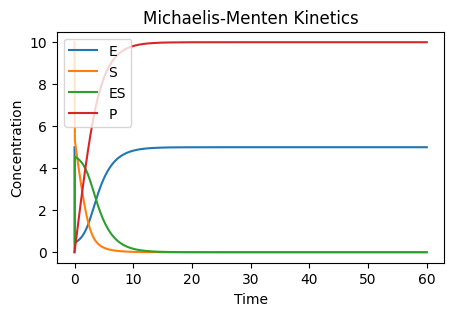

In [6]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Differential equations for the Michaelis-Menten kinetics
def model(y, t, kf, kr, kp):
    E, S, ES, P = y

    # Equations
    dEdt = -kf * E * S + kr * ES + kp * ES
    dSdt = -kf * E * S + kr * ES
    dESdt = kf * E * S - kr * ES - kp * ES
    dPdt = kp * ES

    return [dEdt, dSdt, dESdt, dPdt]

# Initial conditions
E0 = 5     # Initial enzyme concentration
S0 = 10.0    # Initial substrate concentration
ES0 = 0.0    # Initial enzyme-substrate complex concentration
P0 = 0.0     # Initial product concentration

# Parameters
kf = 20     # Forward rate constant for E + S -> ES
kr = 10     # Reverse rate constant for ES -> E + S
kp = 0.5     # Rate constant for ES -> E + P

# Time points to solve at
t = np.linspace(0, 60, 1000)

# Solve the ODEs
results = odeint(model, [E0, S0, ES0, P0], t, args=(kf, kr, kp))

# Plot the results
plt.figure(figsize=(5, 3))
plt.plot(t, results[:, 0], label="E")
plt.plot(t, results[:, 1], label="S")
plt.plot(t, results[:, 2], label="ES")
plt.plot(t, results[:, 3], label="P")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.title("Michaelis-Menten Kinetics")
plt.show()


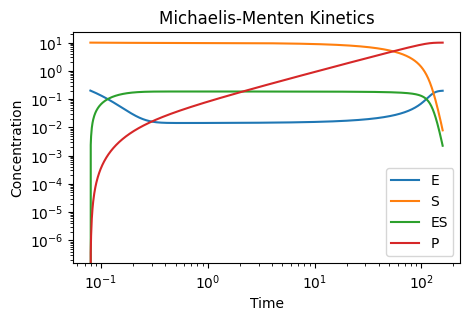

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Differential equations for the Michaelis-Menten kinetics
def model(y, t, kf, kr, kp):
    E, S, ES, P = y

    # Equations
    dEdt = -kf * E * S + kr * ES + kp * ES
    dSdt = -kf * E * S + kr * ES
    dESdt = kf * E * S - kr * ES - kp * ES
    dPdt = kp * ES

    return [dEdt, dSdt, dESdt, dPdt]

# Initial conditions
E0 = 0.2     # Initial enzyme concentration
S0 = 10.0    # Initial substrate concentration
ES0 = 0.0    # Initial enzyme-substrate complex concentration
P0 = 0.0     # Initial product concentration

# Parameters
kf = 2     # Forward rate constant for E + S -> ES
kr = 1     # Reverse rate constant for ES -> E + S
kp = 0.5     # Rate constant for ES -> E + P

# Time points to solve at
logt = np.linspace(-1.1, 2.2, 1000)
t = 10**logt
# Solve the ODEs
results = odeint(model, [E0, S0, ES0, P0], t, args=(kf, kr, kp))

# Plot the results
plt.figure(figsize=(5, 3))
plt.loglog(t, results[:, 0], label="E")
plt.loglog(t, results[:, 1], label="S")
plt.loglog(t, results[:, 2], label="ES")
plt.loglog(t, results[:, 3], label="P")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.title("Michaelis-Menten Kinetics")
plt.show()


### Quasi-Steady-State Approximation (QSSA)
The QSSA assumes that after a short initial period, the rate of formation and breakdown of the ES complex reaches a quasi-steady state. This means:

d(ES)/dt ~ 0

Using this assumption, one can derive the Michaelis-Menten equation mentioned above, where  KM = (kr + k2) / kp.

The Michaelis-Menten model describes how the rate of reaction (velocity, v) between an enzyme and its substrate changes as the substrate concentration increases. It is represented by the equation:

v = v_max [S]/(KM + [S])

Where:
- v is the rate of the reaction.
- v_max is the maximum rate achieved by the system.
- KM is the Michaelis constant, which is the substrate concentration at which the reaction rate is half of \( V_{max} \).
- [S] is the substrate concentration.

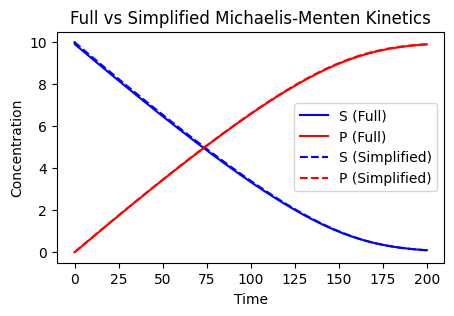

In [3]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Full model
def full_model(y, t, kf, kr, kp):
    E, S, ES, P = y
    dEdt = -kf * E * S + kr * ES + kp * ES
    dSdt = -kf * E * S + kr * ES
    dESdt = kf * E * S - kr * ES - kp * ES
    dPdt = kp * ES
    return [dEdt, dSdt, dESdt, dPdt]

# Simplified model
def simplified_model(y, t, Vmax, KM):
    S, P = y
    dSdt = -Vmax * S / (KM + S)
    dPdt = Vmax * S / (KM + S)
    return [dSdt, dPdt]

# Initial conditions and parameters
E0 = 0.1
S0 = 10
P0 = 0.0
kf = 1.0
kr = 0.5
kp = 0.8
Vmax = kp * E0
KM = (kr + kp) / kf

t = np.linspace(0, 200, 1000)

# Solve the ODEs
full_results = odeint(full_model, [E0, S0, 0, P0], t, args=(kf, kr, kp))
simplified_results = odeint(simplified_model, [S0, P0], t, args=(Vmax, KM))

# Plot the results
plt.figure(figsize=(5, 3))
plt.plot(t, full_results[:, 1], 'b-', label="S (Full)")
plt.plot(t, full_results[:, 3], 'r-', label="P (Full)")
plt.plot(t, simplified_results[:, 0], 'b--', label="S (Simplified)")
plt.plot(t, simplified_results[:, 1], 'r--', label="P (Simplified)")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.title("Full vs Simplified Michaelis-Menten Kinetics")
plt.show()
